# Classification tests on NISAR vs Sentinel-1
Jillian Greene

In [1]:
import rasterio
from rasterio.plot import show_hist
import matplotlib.pyplot as pyplot
from skimage.filters import threshold_otsu
from matplotlib.colors import ListedColormap
import numpy as np
import os

# os.path.join with cwd and data/s2_20190831
s1_folder = os.path.join(os.getcwd(), "data", "nisar_s1_figure", "S1", 'S1_C-band_12172025_VV_clip.tif')
print("s2_folder is: ", s1_folder) # check we're in the right location
# Read in dataset
# s1 = rasterio.open(os.path.join(s1_folder, 'S1_C-band_12172025_VV_clip.tif')) 

# nisar image
nisar_folder = os.path.join(os.getcwd(), "data", "nisar_s1_figure", "NISAR", "NISAR_L2_PR_GCOV_20251216_HH_clip.tif")
print("NISAR_folder is: ", nisar_folder) # check we're in the right location
# nisar = rasterio.open(os.path.join(nisar_folder, "NISAR_L2_PR_GCOV_20251216_HH_clip.tif"))

s2_folder is:  /Volumes/HP500/NCSU/p1/data/nisar_s1_figure/S1/S1_C-band_12172025_VV_clip.tif
NISAR_folder is:  /Volumes/HP500/NCSU/p1/data/nisar_s1_figure/NISAR/NISAR_L2_PR_GCOV_20251216_HH_clip.tif


EPSG:32610


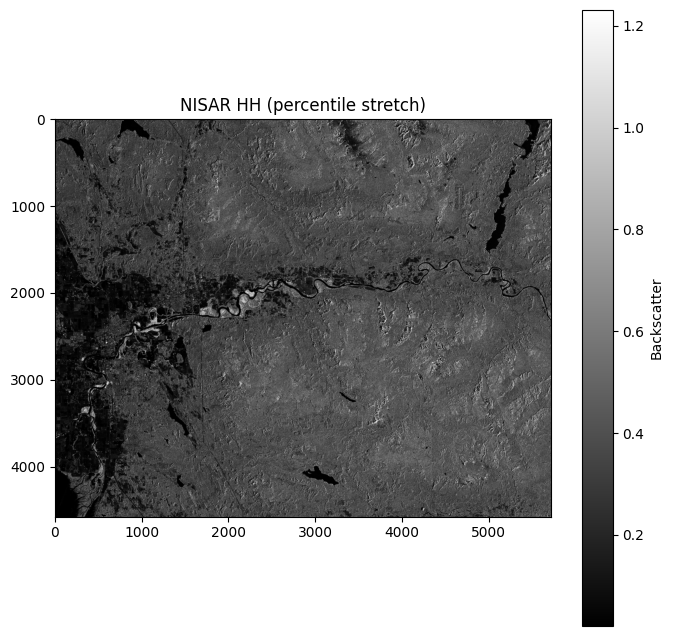

In [2]:
with rasterio.open(nisar_folder) as src:
    print(src.crs)
    data = src.read(1).astype(float)

# Percentile stretch (clips outliers)
p2, p98 = np.percentile(data[data > 0], (2, 98))  # exclude nodata zeros
fig, ax = pyplot.subplots(1, 1, figsize=(8, 8))
im = ax.imshow(data, cmap='gray', vmin=p2, vmax=p98)
pyplot.colorbar(im, ax=ax, label='Backscatter')
ax.set_title("NISAR HH (percentile stretch)")
pyplot.show()

min: 0.0001
max: 2298.3438
mean: 0.3691
median: 0.2896
p2: 0.0207, p98: 1.2313
total pixels: 26149028


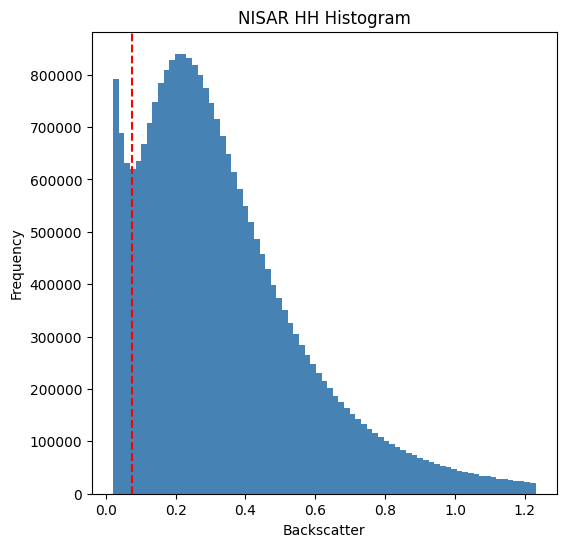

In [3]:
# mask nodata (zeros or NaNs)
valid = data[(data > 0) & np.isfinite(data)]

print(f"min: {valid.min():.4f}")
print(f"max: {valid.max():.4f}")
print(f"mean: {valid.mean():.4f}")
print(f"median: {np.median(valid):.4f}")
print(f"p2: {p2:.4f}, p98: {p98:.4f}")
print(f"total pixels: {len(valid)}")

fig, ax = pyplot.subplots(1, 1, figsize=(6, 6))
ax.hist(valid, bins=75, range=(p2, p98), color='steelblue', edgecolor='none')
ax.axvline(x=0.075, color='red', linestyle='--', linewidth=1.5, label='Threshold (0.075)')
ax.set_title("NISAR HH Histogram")
ax.set_xlabel("Backscatter")
ax.set_ylabel("Frequency")
pyplot.show()

Otsu threshold: 0.4298


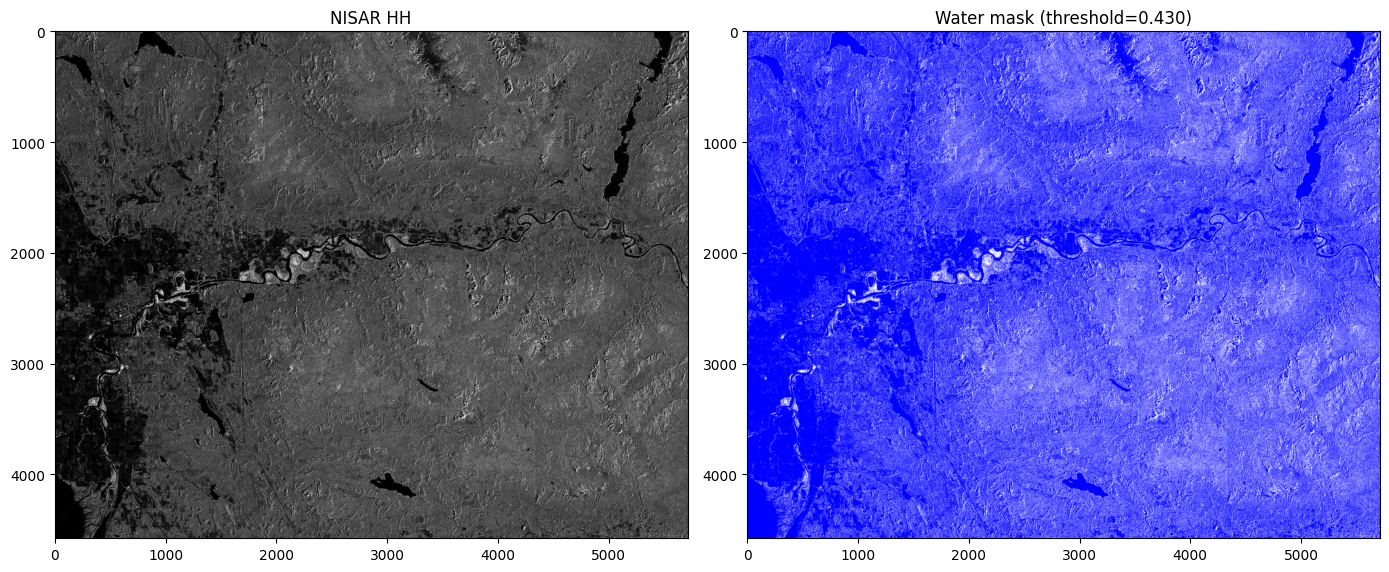

In [4]:
# Otsu Threshold

# Run Otsu only on the clipped range to avoid outlier influence
thresh = threshold_otsu(valid[(valid >= p2) & (valid <= p98)])
print(f"Otsu threshold: {thresh:.4f}")

# Apply threshold to full data — water is typically LOW backscatter
water_mask = (data > 0) & (data < thresh)  # exclude nodata zeros

# Plot the classification
fig, axes = pyplot.subplots(1, 2, figsize=(14, 6))

# Original image
axes[0].imshow(data, cmap='gray', vmin=p2, vmax=p98)
axes[0].set_title("NISAR HH")

# Classified
# Binary cmap
cmap = ListedColormap(['white', 'blue'])
axes[1].imshow(water_mask, cmap=cmap, vmin = 0, vmax = 1)
axes[1].set_title(f"Water mask (threshold={thresh:.3f})")

pyplot.tight_layout()
pyplot.show()

Otsu threshold: 0.0750


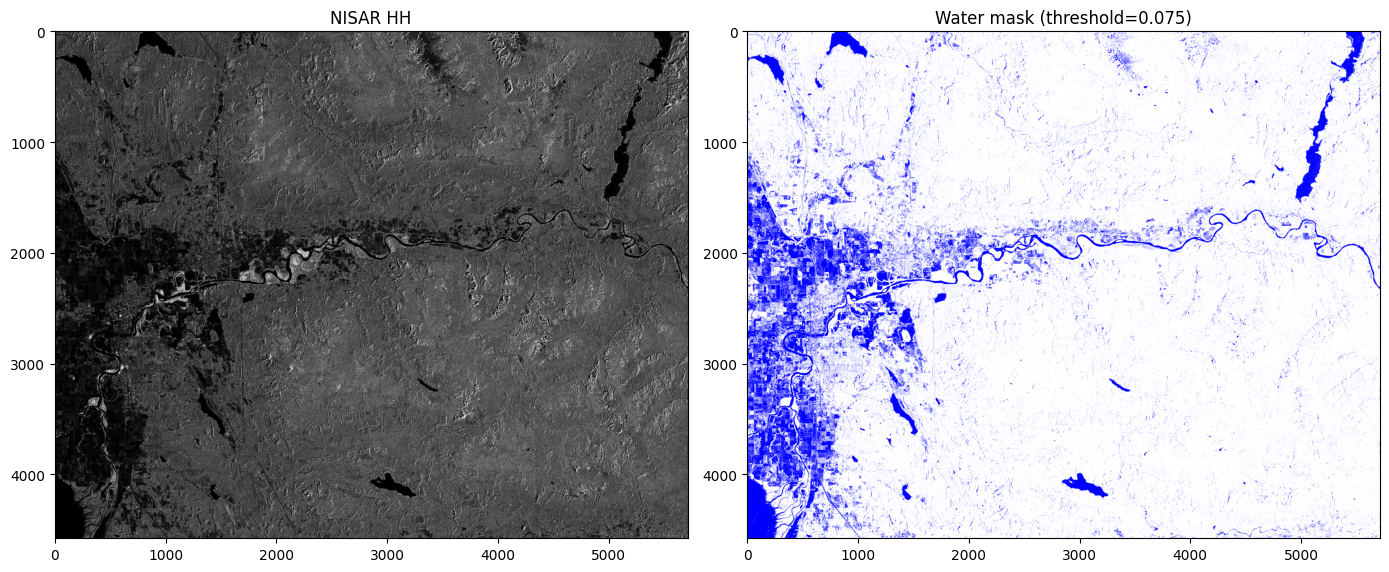

In [5]:
# Manual threshold based on histogram
man_thresh = 0.075
print(f"Otsu threshold: {man_thresh:.4f}")

# Apply threshold to full data — water is typically LOW backscatter
water_mask = (data > 0) & (data < man_thresh)  # exclude nodata zeros

# Plot the classification
fig, axes = pyplot.subplots(1, 2, figsize=(14, 6))

# Original image
axes[0].imshow(data, cmap='gray', vmin=p2, vmax=p98)
axes[0].set_title("NISAR HH")

# Classified
# Binary cmap
cmap = ListedColormap(['white', 'blue'])
axes[1].imshow(water_mask, cmap=cmap, vmin = 0, vmax = 1)
axes[1].set_title(f"Water mask (threshold={man_thresh:.3f})")

pyplot.tight_layout()
pyplot.show()

In [6]:
with rasterio.open(nisar_folder) as src:
    meta = src.meta.copy()

# Update metadata for a binary uint8 single-band raster
meta.update({
    'dtype': 'uint8',
    'count': 1,
    'nodata': 255
})

with rasterio.open('nisar_water_mask.tif', 'w', **meta) as dst:
    dst.write(water_mask.astype('uint8'), 1)

EPSG:32610


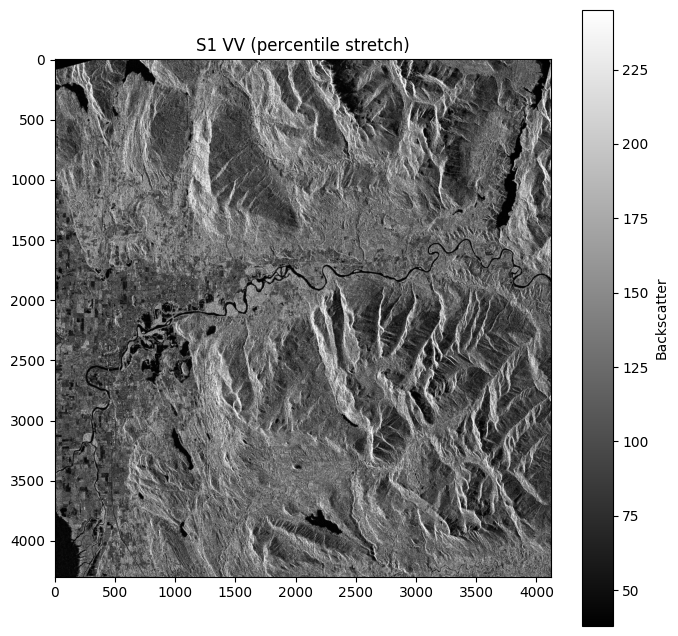

In [7]:
with rasterio.open(s1_folder) as src:
    print(src.crs)
    s1_data = src.read(1).astype(float)

s1_p2, s1_p98 = np.percentile(s1_data[s1_data > 0], (2, 98))

fig, ax = pyplot.subplots(1, 1, figsize=(8, 8))
im = ax.imshow(s1_data, cmap='gray', vmin=s1_p2, vmax=s1_p98)
pyplot.colorbar(im, ax=ax, label='Backscatter')
ax.set_title("S1 VV (percentile stretch)")
pyplot.show()



min: 7.0000
max: 2592.0000
mean: 117.1129
median: 110.0000
p2: 38.0000, p98: 245.0000
total pixels: 17687918


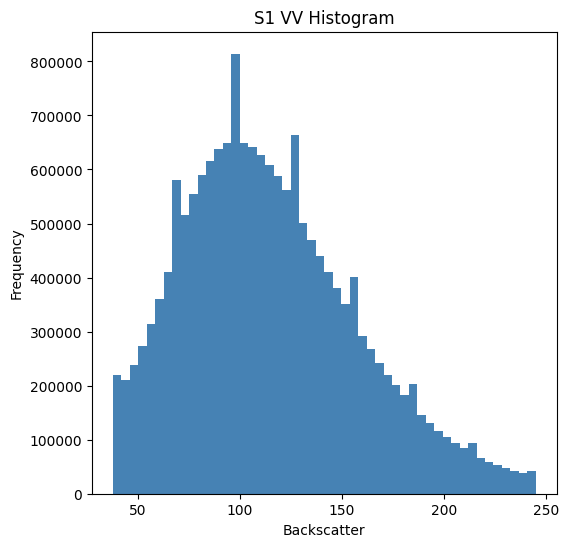

In [8]:
s1_valid = s1_data[(s1_data > 0) & np.isfinite(s1_data)]

print(f"min: {s1_valid.min():.4f}")
print(f"max: {s1_valid.max():.4f}")
print(f"mean: {s1_valid.mean():.4f}")
print(f"median: {np.median(s1_valid):.4f}")
print(f"p2: {s1_p2:.4f}, p98: {s1_p98:.4f}")
print(f"total pixels: {len(s1_valid)}")

fig, ax = pyplot.subplots(1, 1, figsize=(6, 6))
ax.hist(s1_valid, bins=50, range=(s1_p2, s1_p98), color='steelblue', edgecolor='none')
# ax.axvline(x=0.075, color='red', linestyle='--', linewidth=1.5, label='Threshold (0.075)')
ax.set_title("S1 VV Histogram")
ax.set_xlabel("Backscatter")
ax.set_ylabel("Frequency")
pyplot.show()

Otsu threshold: 48.0000


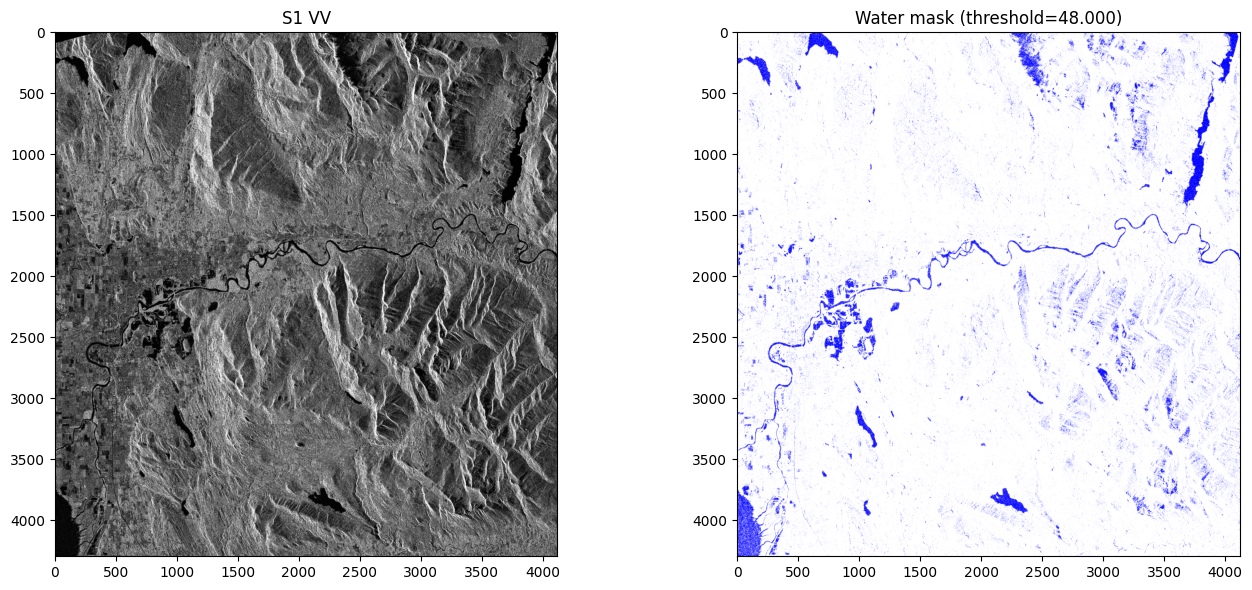

In [9]:
# Run Otsu only on the clipped range to avoid outlier influence
# s1_thresh = threshold_otsu(s1_valid[(s1_valid >= s1_p2) & (s1_valid <= s1_p98)])
s1_thresh = 48
print(f"Otsu threshold: {s1_thresh:.4f}")

# Apply threshold to full data — water is typically LOW backscatter
s1_water_mask = (s1_data > 0) & (s1_data < s1_thresh)  # exclude nodata zeros

# Plot the classification
fig, axes = pyplot.subplots(1, 2, figsize=(14, 6))

# Original image
axes[0].imshow(s1_data, cmap='gray', vmin=s1_p2, vmax=s1_p98)
axes[0].set_title("S1 VV")

# Classified
# Binary cmap
cmap = ListedColormap(['white', 'blue'])
axes[1].imshow(s1_water_mask, cmap=cmap, vmin = 0, vmax = 1)
axes[1].set_title(f"Water mask (threshold={s1_thresh:.3f})")

pyplot.tight_layout()
pyplot.show()

In [10]:
# Export binary layers as tif
with rasterio.open(s1_folder) as src:
    meta = src.meta.copy()

# Update metadata for a binary uint8 single-band raster
meta.update({
    'dtype': 'uint8',
    'count': 1,
    'nodata': 255
})

with rasterio.open('s1_water_mask.tif', 'w', **meta) as dst:
    dst.write(s1_water_mask.astype('uint8'), 1)